Highest epoch saved is 60
Best (epoch_ind, seed_ind) list is [(50, 8), (20, 8), (40, 2), (50, 4), (40, 4), (50, 2), (50, 8), (20, 3)]


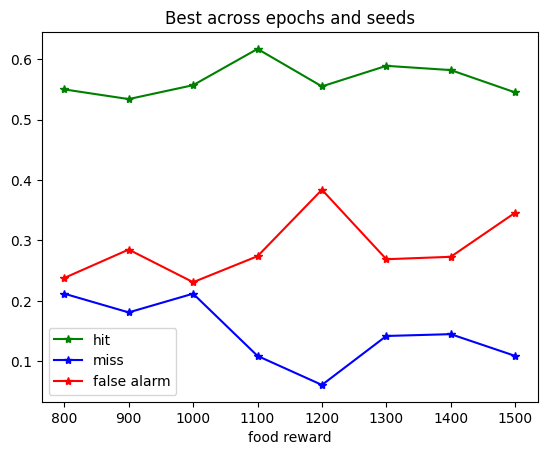

food_reward_list is [800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0, 1500.0]
hit_count_list is [0.55, 0.534, 0.557, 0.617, 0.555, 0.589, 0.582, 0.545]
miss_count_list is [0.212, 0.181, 0.212, 0.109, 0.061, 0.142, 0.145, 0.109]
false_alarm_list is [0.238, 0.285, 0.231, 0.274, 0.384, 0.269, 0.273, 0.346]


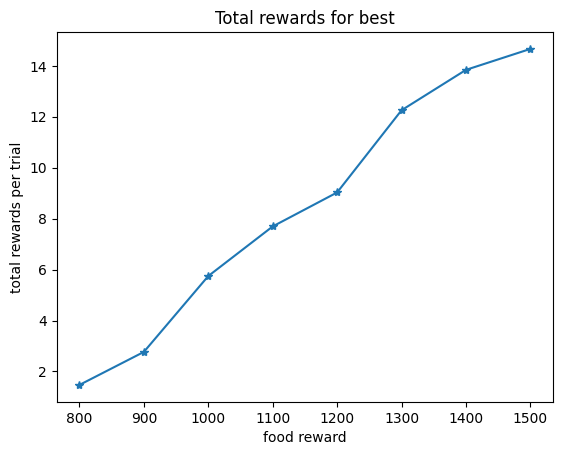

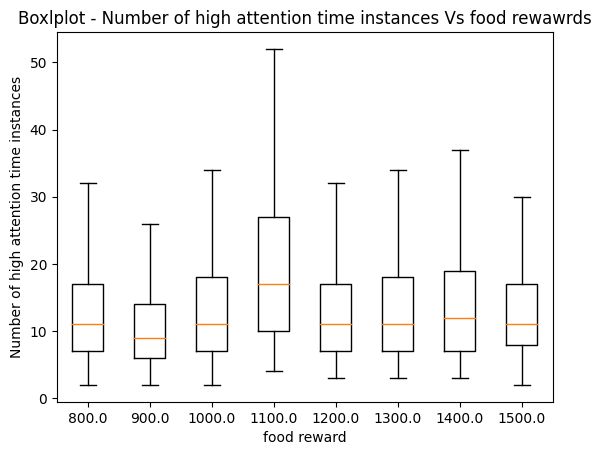

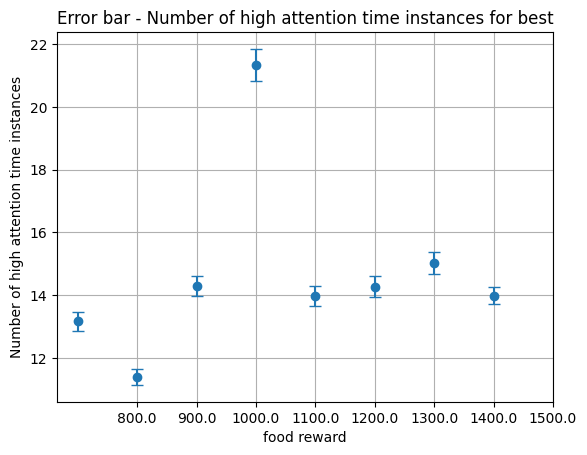

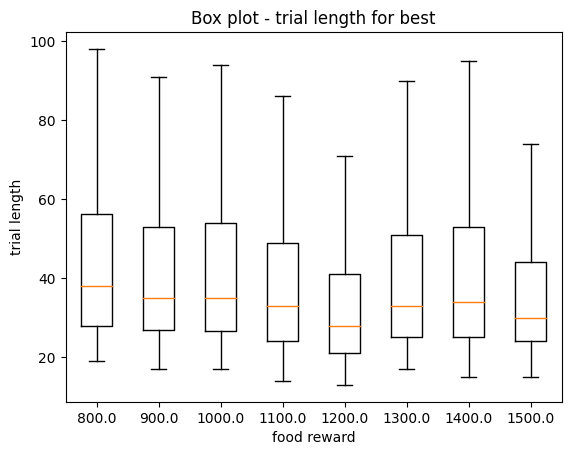

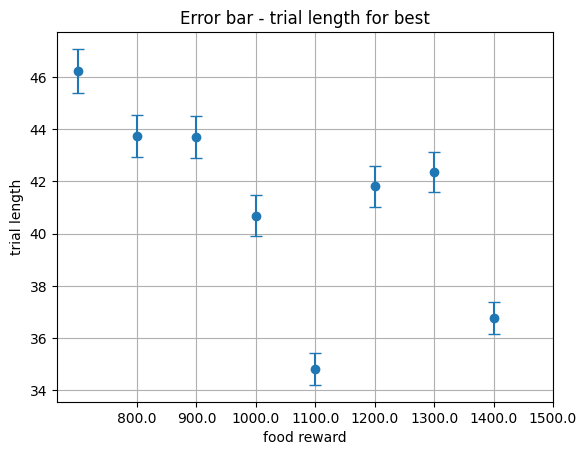

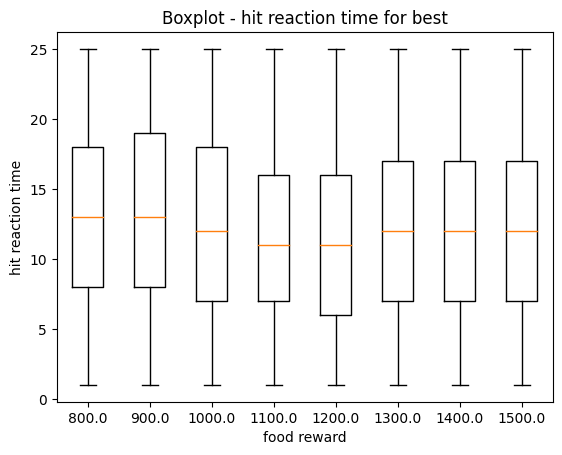

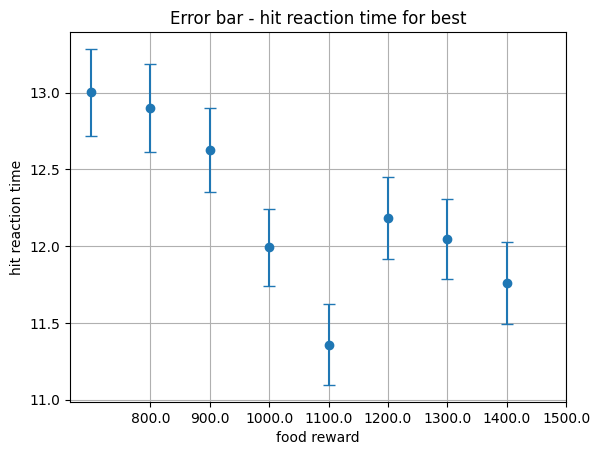

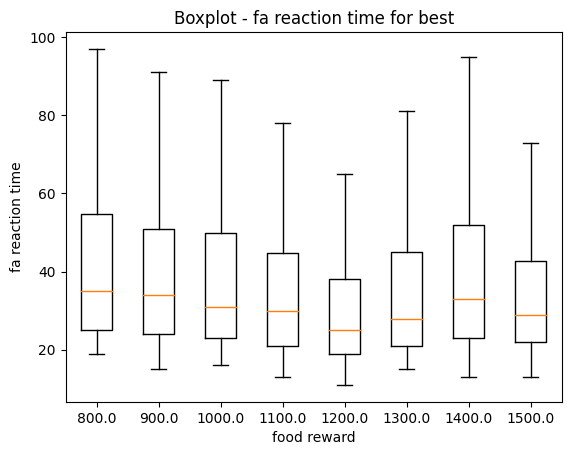

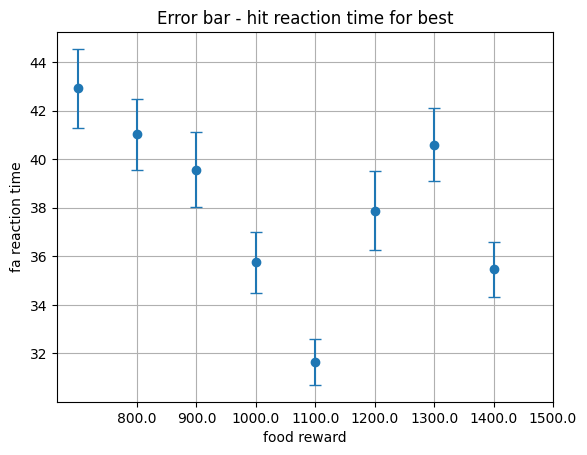

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from auditoryforage.utils import open_pickle_file, find_recent_epoch
no_seeds = 10
folder_name = './store/comparison/'
pattern = f'#seeds_{no_seeds}_#epochs_'
start_model_no = 0
epoch_increments_saved = 10

max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)
# max_epoch_val = 50

num_models = int(max_epoch_val/epoch_increments_saved)

def setup_measure_matrix(start_model_no, num_models, measure, no_seeds):
    # In general
        # dim 0 different epochs.
        # dim 1 is seed
    
        # dim 2 different exp no.
    # For best_seed_list
        # dim 0 different epochs.
        # dim 1 different exp no.

    epochs_list =  [(elt + 1) * epoch_increments_saved for elt in range(start_model_no, num_models)]
    measure_matrix = []
    for epoch in epochs_list:
        file_name = folder_name + f'#seeds_{no_seeds}_#epochs_{epoch}.pkl'
        detection_measures = open_pickle_file(file_name)
        if measure == 'best_seed_list':
            measure_matrix.append([curr_elt for curr_elt in detection_measures['output'][measure]])
        elif measure in ['attention_time_points_list', 'episode_length_list','hit_reaction_time_list','fa_reaction_time_list']:
            measure_matrix.append([])
            for seed_index in range(no_seeds):
                measure_matrix[-1].append([curr_elt[seed_index] for curr_elt in detection_measures['output'][measure]])
        elif measure in ['hit_count_list', 'miss_count_list', 'false_alarm_list', 'total_reward_list_across_exps']:
            measure_matrix.append([])
            for seed_index in range(no_seeds):
                measure_matrix[-1].append([curr_elt[seed_index]/detection_measures['input']['no_episodes'] for curr_elt in detection_measures['output'][measure]])
        
    
    if measure not in ['attention_time_points_list', 'episode_length_list','hit_reaction_time_list','fa_reaction_time_list']: 
        measure_matrix = np.array(measure_matrix)
    food_reward_list = detection_measures['input']['food_reward_list']
    return epochs_list, food_reward_list, measure_matrix

def extract_info_across_seeds(no_seeds):
    # For best_seed_list
    # dim 0 different exp no.
    # dim 1 (epoch_ind, seed_ind).

    across_seeds_dict = {}
    across_seeds_dict['epochs_list'], across_seeds_dict['food_reward_list'], across_seeds_dict['total_reward_matrix'] = setup_measure_matrix(start_model_no, num_models, 'total_reward_list_across_exps', no_seeds)
    _, _, across_seeds_dict['hit_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'hit_count_list', no_seeds)
    _, _, across_seeds_dict['miss_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'miss_count_list', no_seeds)
    _, _, across_seeds_dict['false_alarm_matrix'] = setup_measure_matrix(start_model_no, num_models, 'false_alarm_list', no_seeds)
    _, _, across_seeds_dict['best_seed_matrix'] = setup_measure_matrix(start_model_no, num_models, 'best_seed_list', no_seeds)
    _, _, across_seeds_dict['attention_time_points_matrix'] = setup_measure_matrix(start_model_no, num_models, 'attention_time_points_list', no_seeds)
    _, _, across_seeds_dict['episode_length_matrix'] = setup_measure_matrix(start_model_no, num_models, 'episode_length_list', no_seeds)
    _, _, across_seeds_dict['hit_reaction_time_matrix'] = setup_measure_matrix(start_model_no, num_models, 'hit_reaction_time_list', no_seeds)
    _, _, across_seeds_dict['fa_reaction_time_matrix'] = setup_measure_matrix(start_model_no, num_models, 'fa_reaction_time_list', no_seeds)
    max_total_rewards = np.max(across_seeds_dict['total_reward_matrix'], axis=(0, 1))
    best_epoch_seed_inds = [np.where(across_seeds_dict['total_reward_matrix'][:,:,exp_ind] == max_total_rewards[exp_ind]) for exp_ind in range(len(max_total_rewards))]

    # Manual check
    # epoch = int(max_epoch_val/epoch_increments_saved-1)
    # seed = 0
    # best_epoch_seed_inds = [(np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed])), (np.array([epoch]), np.array([seed]))]
    
    across_seeds_dict['best_epoch_seed_inds'] = [(elt[0][0], elt[1][0]) for elt in best_epoch_seed_inds]
    return across_seeds_dict

def visualize_output(no_seeds):
    across_seeds_dict = extract_info_across_seeds(no_seeds)
    total_reward_matrix = across_seeds_dict['total_reward_matrix']
    hit_count_matrix = across_seeds_dict['hit_count_matrix']
    miss_count_matrix = across_seeds_dict['miss_count_matrix']
    false_alarm_matrix = across_seeds_dict['false_alarm_matrix']
    best_epoch_seed_inds = across_seeds_dict['best_epoch_seed_inds']
    food_reward_list = across_seeds_dict['food_reward_list']
    epochs_list = across_seeds_dict['epochs_list']
    attention_time_points_matrix = across_seeds_dict['attention_time_points_matrix']
    episode_length_matrix = across_seeds_dict['episode_length_matrix']
    hit_reaction_time_matrix = across_seeds_dict['hit_reaction_time_matrix']
    fa_reaction_time_matrix = across_seeds_dict['fa_reaction_time_matrix']

    def plot_hit_miss_FA(x_axis_list, hit_count_list, miss_count_list, false_alarm_list, title = ''):
        plt.figure()
        plt.plot(x_axis_list, hit_count_list, '-*g')
        plt.plot(x_axis_list, miss_count_list, '-*b')
        plt.plot(x_axis_list, false_alarm_list, '-*r')
        plt.legend(['hit', 'miss', 'false alarm'])
        plt.xlabel('food reward') if x_axis_list == food_reward_list else plt.xlabel('epochs')
        plt.title(title)
        plt.show()
            
    def plot_hit_miss_FA_for_best():
        hit_count_list = [hit_count_matrix[best_epoch_seed_inds[exp_ind][0], best_epoch_seed_inds[exp_ind][1], exp_ind] for exp_ind in range(len(food_reward_list))]
        miss_count_list = [miss_count_matrix[best_epoch_seed_inds[exp_ind][0], best_epoch_seed_inds[exp_ind][1], exp_ind] for exp_ind in range(len(food_reward_list))]
        false_alarm_list = [false_alarm_matrix[best_epoch_seed_inds[exp_ind][0], best_epoch_seed_inds[exp_ind][1], exp_ind] for exp_ind in range(len(food_reward_list))]
        title = 'Best across epochs and seeds'
        plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, title)
        print(f'food_reward_list is {food_reward_list}')         
        print(f'hit_count_list is {hit_count_list}')         
        print(f'miss_count_list is {miss_count_list}')         
        print(f'false_alarm_list is {false_alarm_list}')  

    def plot_no_high_att_for_best():
        attention_time_points_list = [attention_time_points_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind] for exp_ind in range(len(food_reward_list))]
        no_attention_list = []
        for ind in range(len(attention_time_points_list)):
            no_attention_list.append([len(episode) for episode in attention_time_points_list[ind]])
                  
        plt.figure()
        plt.boxplot(no_attention_list, showfliers=False)
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.xlabel('food reward')
        plt.ylabel(f'Number of high attention time instances')
        plt.title(f'Boxlplot - Number of high attention time instances Vs food rewawrds')
        plt.show()

        plt.figure()
        mean_list = [np.mean(no_attention_list[exp_ind]) for exp_ind in range(len(food_reward_list))]
        sem_list = [np.std(no_attention_list[exp_ind])/np.sqrt(np.size(no_attention_list[exp_ind])) for exp_ind in range(len(food_reward_list))]
        plt.errorbar([str(food_reward) for food_reward in food_reward_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
        plt.xlabel('food reward')
        plt.ylabel(f'Number of high attention time instances')
        plt.title(f'Error bar - Number of high attention time instances for best')
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.grid()
        plt.show()

    def plot_trial_length_for_best():
        episode_length_list = [episode_length_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind] for exp_ind in range(len(food_reward_list))]
        plt.figure()
        plt.boxplot(episode_length_list, showfliers=False)
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.ylabel(f'trial length')
        plt.title(f'Box plot - trial length for best')
        plt.xlabel('food reward')
        plt.show()

        plt.figure()
        mean_list = [np.mean(episode_length_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind]) for exp_ind in range(len(food_reward_list))]
        sem_list = [np.std(episode_length_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind])/np.sqrt(np.size(episode_length_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind])) for exp_ind in range(len(food_reward_list))]
        plt.errorbar([str(food_reward) for food_reward in food_reward_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
        plt.xlabel('food reward')
        plt.ylabel(f'trial length')
        plt.title(f'Error bar - trial length for best')
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.grid()
        plt.show()

    def plot_hit_reaction_time_for_best():
        hit_reaction_time_list = [hit_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind] for exp_ind in range(len(food_reward_list))]
        plt.figure()
        plt.boxplot(hit_reaction_time_list, showfliers=False)
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.ylabel(f'hit reaction time')
        plt.title(f'Boxplot - hit reaction time for best')
        plt.xlabel('food reward')
        plt.show()

        plt.figure()
        mean_list = [np.mean(hit_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind]) for exp_ind in range(len(food_reward_list))]
        sem_list = [np.std(hit_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind])/np.sqrt(np.size(hit_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind])) for exp_ind in range(len(food_reward_list))]
        plt.errorbar([str(food_reward) for food_reward in food_reward_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
        plt.xlabel('food reward')
        plt.ylabel(f'hit reaction time')
        plt.title(f'Error bar - hit reaction time for best')
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.grid()
        plt.show()

    def plot_fa_reaction_time_for_best():
        fa_reaction_time_list = [fa_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind] for exp_ind in range(len(food_reward_list))]
        plt.figure()
        plt.boxplot(fa_reaction_time_list, showfliers=False)
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.ylabel(f'fa reaction time')
        plt.title(f'Boxplot - fa reaction time for best')
        plt.xlabel('food reward')
        plt.show()

        plt.figure()
        mean_list = [np.mean(fa_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind]) for exp_ind in range(len(food_reward_list))]
        sem_list = [np.std(fa_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind])/np.sqrt(np.size(fa_reaction_time_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind])) for exp_ind in range(len(food_reward_list))]
        plt.errorbar([str(food_reward) for food_reward in food_reward_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
        plt.xlabel('food reward')
        plt.ylabel(f'fa reaction time')
        plt.title(f'Error bar - hit reaction time for best')
        plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
        plt.grid()
        plt.show()
    
    def plot_total_reward_for_best():
        plt.figure()
        plt.plot(food_reward_list, [total_reward_matrix[best_epoch_seed_inds[exp_ind][0]][best_epoch_seed_inds[exp_ind][1]][exp_ind] for exp_ind in range(len(food_reward_list))],'*-')
        plt.xlabel('food reward')
        plt.ylabel('total rewards per trial')
        plt.title(f'Total rewards for best')
        plt.show()

    def plot_reward_progression_per_seed_per_exp(seed_index, exp_index):
        plt.figure()
        plt.plot(epochs_list, [total_reward_matrix[epoch_ind][seed_index][exp_index] for epoch_ind in range(len(epochs_list))],'*-')
        plt.xlabel('epoch number')
        plt.ylabel('rewards per trial')
        plt.title(f'Rewards per trial progression  across epochs for exp_ind {exp_index} and seed {seed_index}')
        plt.show()

    
    
    def visualize_per_seed_index(seed_index):
        best_epoch_list = np.argmax(total_reward_matrix[:][seed_index][:],0)

        def plot_hit_miss_FA_for_best_epoch():
            hit_count_list = [hit_count_matrix[epoch_ind][seed_index][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))]
            miss_count_list = [miss_count_matrix[epoch_ind][seed_index][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))]
            false_alarm_list = [false_alarm_matrix[epoch_ind][seed_index][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))]
            title = f'Performance of best epochs for seed index {seed_index}'
            plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, title)          
        
        def plot_reward_per_trial_for_best_epoch():
            plt.figure()
            plt.plot(food_reward_list, [total_reward_matrix[epoch_ind][seed_index][exp_ind] for epoch_ind, exp_ind in zip(best_epoch_list, range(len(best_epoch_list)))],'*-')
            plt.xlabel('food reward')
            plt.ylabel('reward per trial')
            plt.title(f'Rewards per trial for best epochs for seed {seed_index}')
            plt.show()

        def plot_best_epoch():
            plt.figure()
            plt.stem(food_reward_list, [epochs_list[best_ind] for best_ind in best_epoch_list])
            plt.xlabel('food reward')
            plt.ylabel('best epoch')
            plt.title(f'Best epoch for seed {seed_index}')
            plt.show()

        plot_hit_miss_FA_for_best_epoch()
        plot_reward_per_trial_for_best_epoch()
        plot_best_epoch()

    print(f'Best (epoch_ind, seed_ind) list is {[(elt[0] * epoch_increments_saved, elt[1]) for elt in best_epoch_seed_inds]}')
    plot_hit_miss_FA_for_best()
    plot_total_reward_for_best()
    plot_no_high_att_for_best()
    plot_trial_length_for_best()
    plot_hit_reaction_time_for_best()
    plot_fa_reaction_time_for_best()
    # plot_reward_progression_per_seed_per_exp(seed_index = 0, exp_index = -1)
    # visualize_per_seed_index(seed_index = 0)


across_seeds_dict = visualize_output(no_seeds)

In [2]:
no_seeds


across_seeds_dict = extract_info_across_seeds(no_seeds)
# total_reward_matrix = across_seeds_dict['total_reward_matrix']
# hit_count_matrix = across_seeds_dict['hit_count_matrix']
# miss_count_matrix = across_seeds_dict['miss_count_matrix']
# false_alarm_matrix = across_seeds_dict['false_alarm_matrix']
# best_epoch_seed_inds = across_seeds_dict['best_epoch_seed_inds']
# food_reward_list = across_seeds_dict['food_reward_list']
# epochs_list = across_seeds_dict['epochs_list']
# attention_time_points_matrix = across_seeds_dict['attention_time_points_matrix']
# episode_length_matrix = across_seeds_dict['episode_length_matrix']

In [3]:
file_name = folder_name + f'#seeds_{no_seeds}_#epochs_{epoch}.pkl'
detection_measures = open_pickle_file(file_name)
# if measure == 'best_seed_list':
#     measure_matrix.append([curr_elt for curr_elt in detection_measures['output'][measure]])

NameError: name 'epoch' is not defined

In [ ]:
file_name = folder_name + f'#seeds_{no_seeds}_#epochs_{2300}.pkl'
detection_measures = open_pickle_file(file_name)
reaction_time = []
for ind in range(len(detection_measures['output']['best_seed_list'])):
    best_seed = detection_measures['output']['best_seed_list'][ind]
    hit_count = detection_measures['output']['hit_count_list'][ind][best_seed]
    signal_time_before_lick_list = detection_measures['output']['signal_time_before_lick_list'][ind][best_seed]
    if hit_count == 0:
        reaction_time.append(0)
    else:
        reaction_time.append(signal_time_before_lick_list/hit_count)
print(reaction_time)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from auditoryforage.utils import open_pickle_file, find_recent_epoch
no_seeds = 5
folder_name = './store/comparison/'
pattern = f'#seeds_{no_seeds}_#epochs_'
start_model_no = 0
epoch_increments_saved = 20
max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)
num_models = int(max_epoch_val/epoch_increments_saved)

def setup_measure_matrix(start_model_no, num_models, measure, no_seeds):
    # In general
        # dim 0 different epochs.
        # dim 1 is seed
        # dim 2 different exp no.
    # For best_seed_list
        # dim 0 different epochs.
        # dim 1 different exp no.

    epochs_list =  [(elt + 1) * epoch_increments_saved for elt in range(start_model_no, num_models)]
    measure_matrix = []
    for epoch in epochs_list:
        file_name = folder_name + f'#seeds_{no_seeds}_#epochs_{epoch}.pkl'
        detection_measures = open_pickle_file(file_name)
        if measure == 'best_seed_list':
            measure_matrix.append([curr_elt for curr_elt in detection_measures['output'][measure]])
        elif measure == 'attention_time_points_list':
            measure_matrix.append([])
            for seed_index in range(no_seeds):
                measure_matrix[-1].append([curr_elt[seed_index] for curr_elt in detection_measures['output'][measure]])
        elif measure ==  'episode_length_list':
            measure_matrix.append([])
            for seed_index in range(no_seeds):
                measure_matrix[-1].append([curr_elt[seed_index] for curr_elt in detection_measures['output'][measure]])
        elif measure ==  'hit_count_list' or measure ==  'miss_count_list' or measure ==  'false_alarm_list' or measure == 'total_reward_list_across_exps':
            measure_matrix.append([])
            for seed_index in range(no_seeds):
                measure_matrix[-1].append([curr_elt[seed_index]/detection_measures['input']['no_episodes'] for curr_elt in detection_measures['output'][measure]])
        
    
    
    if measure not in ['attention_time_points_list', 'episode_length_list']: 
        measure_matrix = np.array(measure_matrix)
    food_reward_list = detection_measures['input']['food_reward_list']
    return epochs_list, food_reward_list, measure_matrix

def extract_info_across_seeds(no_seeds):
    # For best_seed_list
    # dim 0 different exp no.
    # dim 1 (epoch_ind, seed_ind).

    across_seeds_dict = {}
    across_seeds_dict['epochs_list'], across_seeds_dict['food_reward_list'], across_seeds_dict['total_reward_matrix'] = setup_measure_matrix(start_model_no, num_models, 'total_reward_list_across_exps', no_seeds)
    _, _, across_seeds_dict['hit_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'hit_count_list', no_seeds)
    _, _, across_seeds_dict['miss_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'miss_count_list', no_seeds)
    _, _, across_seeds_dict['false_alarm_matrix'] = setup_measure_matrix(start_model_no, num_models, 'false_alarm_list', no_seeds)
    _, _, across_seeds_dict['best_seed_matrix'] = setup_measure_matrix(start_model_no, num_models, 'best_seed_list', no_seeds)
    _, _, across_seeds_dict['attention_time_points_matrix'] = setup_measure_matrix(start_model_no, num_models, 'attention_time_points_list', no_seeds)
    _, _, across_seeds_dict['episode_length_matrix'] = setup_measure_matrix(start_model_no, num_models, 'episode_length_list', no_seeds)
    max_total_rewards = np.max(across_seeds_dict['total_reward_matrix'], axis=(0, 1))
    best_epoch_seed_inds = [np.where(across_seeds_dict['total_reward_matrix'][:,:,exp_ind] == max_total_rewards[exp_ind]) for exp_ind in range(len(max_total_rewards))]
    across_seeds_dict['best_epoch_seed_inds'] = [(elt[0][0], elt[1][0]) for elt in best_epoch_seed_inds]

    return across_seeds_dict, best_epoch_seed_inds



across_seeds_dict, best_epoch_seed_inds = extract_info_across_seeds(no_seeds)

No matching files found in the directory.


TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'

In [3]:
for food_ind in range(2,8):
    best_seed = best_epoch_seed_inds[food_ind][1][0]
    best_epoch = epoch_increments_saved * (1 + best_epoch_seed_inds[food_ind][0][0])
    file_name = folder_name + f'#seeds_{no_seeds}_#epochs_{best_epoch}.pkl'
    detection_measures = open_pickle_file(file_name)
    hit_count = detection_measures['output']['hit_count_list'][food_ind][best_seed]
    signal_time_before_lick_list = detection_measures['output']['signal_time_before_lick_list'][food_ind][best_seed]
    if hit_count == 0:
        reaction_time.append(0)
    else:
        reaction_time.append(signal_time_before_lick_list/hit_count)
print(reaction_time)

NameError: name 'best_epoch_seed_inds' is not defined

In [ ]:
def extract_info_across_seeds(no_seeds):
    # For best_seed_list
    # dim 0 different exp no.
    # dim 1 (epoch_ind, seed_ind).

    across_seeds_dict = {}
    across_seeds_dict['epochs_list'], across_seeds_dict['food_reward_list'], across_seeds_dict['total_reward_matrix'] = setup_measure_matrix(start_model_no, num_models, 'total_reward_list_across_exps', no_seeds)
    _, _, across_seeds_dict['hit_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'hit_count_list', no_seeds)
    _, _, across_seeds_dict['miss_count_matrix'] = setup_measure_matrix(start_model_no, num_models, 'miss_count_list', no_seeds)
    _, _, across_seeds_dict['false_alarm_matrix'] = setup_measure_matrix(start_model_no, num_models, 'false_alarm_list', no_seeds)
    _, _, across_seeds_dict['best_seed_matrix'] = setup_measure_matrix(start_model_no, num_models, 'best_seed_list', no_seeds)
    _, _, across_seeds_dict['attention_time_points_matrix'] = setup_measure_matrix(start_model_no, num_models, 'attention_time_points_list', no_seeds)
    _, _, across_seeds_dict['episode_length_matrix'] = setup_measure_matrix(start_model_no, num_models, 'episode_length_list', no_seeds)
    _, _, across_seeds_dict['hit_reaction_time_matrix'] = setup_measure_matrix(start_model_no, num_models, 'hit_reaction_time_list', no_seeds)
    _, _, across_seeds_dict['fa_reaction_time_matrix'] = setup_measure_matrix(start_model_no, num_models, 'fa_reaction_time_list', no_seeds)
    max_total_rewards = np.max(across_seeds_dict['total_reward_matrix'], axis=(0, 1))
    best_epoch_seed_inds = [np.where(across_seeds_dict['total_reward_matrix'][:,:,exp_ind] == max_total_rewards[exp_ind]) for exp_ind in range(len(max_total_rewards))]
    across_seeds_dict['best_epoch_seed_inds'] = [(elt[0][0], elt[1][0]) for elt in best_epoch_seed_inds]

    return across_seeds_dict

across_seeds_dict = extract_info_across_seeds(no_seeds)

In [ ]:
across_seeds_dict['hit_reaction_time_matrix']

In [ ]:
across_seeds_dict['episode_length_matrix']

In [ ]:
across_seeds_dict = extract_info_across_seeds(no_seeds)
across_seeds_dict['best_epoch_seed_inds']

In [ ]:
epochs60 = [0.005635074180816038, 0.11478662894503065, 0.2336641533602331, 0.3982104759401505, 0.6425056079092574, 0.690024400055101, 0.879059801765944, 0.9944691426935377, 1.1444978338830667]
epochs50 = [0.005635074180816038, 0.08147329171139006, 0.22954694814682688, 0.3637271795476045, 0.6425056079092574, 0.690024400055101, 0.879059801765944, 0.9944691426935377, 1.0518850662808743]

In [ ]:
plt.plot(epochs60,label='60')
plt.plot(epochs50,label='50')
plt.legend()